<a href="https://colab.research.google.com/github/sarkarpragati/Machine-Learning-Lab/blob/main/Voting_vs_Bagging_Accuracy_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import VotingClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# Loading dataset
df = pd.read_csv(r"C:\Users\user\Downloads\archive (1)\diabetes.csv")
df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
#Preprocessing
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    if col in df.columns:
        df[col] = df[col].replace(0, df[col].median())

In [ ]:
#MULTI-CLASS TARGET
def classify(val):
    if val == 0:
        return 0   # No diabetes
    else:
        return 2   # Diabetes

df['Target'] = df['Outcome'].apply(classify)

# Add tendency class
df.loc[(df['Glucose'] > 120) & (df['Glucose'] < 140), 'Target'] = 1

df.drop('Outcome', axis=1, inplace=True)


In [ ]:
#FEATURES
X = df.drop('Target', axis=1)
y = df['Target']

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
#MODELS
knn = KNeighborsClassifier()
nb = GaussianNB()
dt = DecisionTreeClassifier()

In [ ]:
# SPLITS
splits = [0.2, 0.3, 0.4, 0.5]

voting_results = []
bagging_results = []

In [ ]:
# LOOP FOR EACH SPLIT
for test_size in splits:

    print("\n==============================")
    print(f"SPLIT {int((1-test_size)*100)}:{int(test_size*100)}")
    print("==============================")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # =========================
    # HARD VOTING
    # =========================
    voting = VotingClassifier(
        estimators=[('knn', knn), ('nb', nb), ('dt', dt)],
        voting='hard'
    )

    voting.fit(X_train, y_train)
    y_vote = voting.predict(X_test)

    acc_vote = accuracy_score(y_test, y_vote)
    voting_results.append(acc_vote)

    print("Voting Accuracy:", acc_vote)

    # =========================
    # BAGGING
    # =========================
    bagging = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=10
    )

    bagging.fit(X_train, y_train)
    y_bag = bagging.predict(X_test)

    acc_bag = accuracy_score(y_test, y_bag)
    bagging_results.append(acc_bag)

    print("Bagging Accuracy:", acc_bag)


SPLIT 80:20
Voting Accuracy: 0.7337662337662337
Bagging Accuracy: 0.7792207792207793

SPLIT 70:30
Voting Accuracy: 0.7402597402597403
Bagging Accuracy: 0.8051948051948052

SPLIT 60:40
Voting Accuracy: 0.7467532467532467
Bagging Accuracy: 0.827922077922078

SPLIT 50:50
Voting Accuracy: 0.7630208333333334
Bagging Accuracy: 0.8359375


In [ ]:
# BEST ACCURACY
best_voting = max(voting_results)
best_bagging = max(bagging_results)

print("FINAL RESULT:")


print("Best Voting Accuracy:", best_voting)
print("Best Bagging Accuracy:", best_bagging)


FINAL RESULT:
Best Voting Accuracy: 0.7630208333333334
Best Bagging Accuracy: 0.8359375


In [ ]:
# FINAL COMPARISON
if best_voting > best_bagging:
    print("Voting is better")
elif best_bagging > best_voting:
    print("Bagging is better")
else:
    print("Both perform equally")

Bagging is better


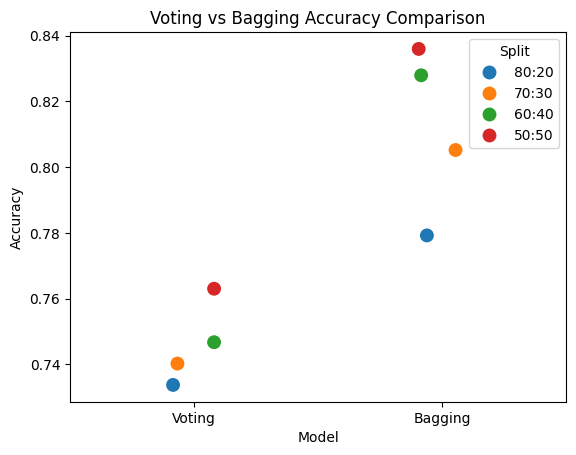

In [ ]:
# STRIP PLOT
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame for plotting
plot_df = pd.DataFrame({
    'Model': ['Voting']*4 + ['Bagging']*4,
    'Accuracy': voting_results + bagging_results,
    'Split': ['80:20', '70:30', '60:40', '50:50']*2
})

# Plot
sns.stripplot(x='Model', y='Accuracy', data=plot_df, hue='Split', size=10)

plt.title("Voting vs Bagging Accuracy Comparison")
plt.show()